# AI-Based Construction Safety Detection using YOLO + Roboflow Dataset

## Workflow

```text
Roboflow Dataset → Download YOLOv8 Format → Train YOLO → Evaluate → Test → Save Model
```

## Step 1: Install Required Libraries

In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 5.6 MB/s eta 0:00:00


## Step 2: Import Libraries

In [2]:
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
from google.colab import files

import os, glob, yaml
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Libraries imported successfully.


## Step 3: Connect Roboflow Dataset

Replace the placeholders with your Roboflow details.

How to get this:
1. Open your Roboflow project.
2. Click **Download Dataset**.
3. Select **YOLOv8** format.
4. Copy your workspace, project, version, and API key.

Example:
```python
rf = Roboflow(api_key="abc123")
project = rf.workspace("my-workspace").project("weapon-detection")
version = project.version(1)
dataset = version.download("yolov8")
```

In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key="zW93fKW8MyzdfNrZnFr6")

project = rf.workspace("roboflow-100").project("construction-safety-gsnvb")

version = project.version(1)

dataset = version.download("yolov8")

print("Dataset downloaded successfully.")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to construction-safety-1 in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 4519.48it/s]

Dataset downloaded successfully.
Dataset location: /content/construction-safety-1


## Step 4: Check Dataset Files

In [7]:
dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml exists:", os.path.exists(data_yaml_path))

print("\nDataset folder content:")
for item in os.listdir(dataset_path):
    print("-", item)

Dataset path: /content/construction-safety-1
data.yaml exists: True

Dataset folder content:
- README.dataset.txt
- data.yaml
- valid
- test
- train
- README.roboflow.txt


## Step 5: Read `data.yaml` and Class Names

In [8]:
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

class_names = data_yaml.get("names", [])
print("\nClasses:", class_names)
print("Number of classes:", len(class_names))

{'names': ['helmet', 'no-helmet', 'no-vest', 'person', 'vest'], 'nc': 5, 'roboflow': {'license': 'CC BY 4.0', 'project': 'construction-safety-gsnvb', 'url': 'https://universe.roboflow.com/roboflow-100/construction-safety-gsnvb/dataset/1', 'version': 1, 'workspace': 'roboflow-100'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Classes: ['helmet', 'no-helmet', 'no-vest', 'person', 'vest']
Number of classes: 5


## Step 6: Count Images in Train, Validation, and Test Sets

In [9]:
def count_images(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    return sum(len(glob.glob(os.path.join(folder, ext))) for ext in exts)

train_img_dir = os.path.join(dataset_path, "train", "images")
valid_img_dir = os.path.join(dataset_path, "valid", "images")
test_img_dir = os.path.join(dataset_path, "test", "images")

counts = {
    "Train Images": count_images(train_img_dir),
    "Validation Images": count_images(valid_img_dir),
    "Test Images": count_images(test_img_dir)
}

pd.DataFrame([counts])

,Train Images,Validation Images,Test Images
0,997,119,90


## Step 7: Preview Sample Training Images

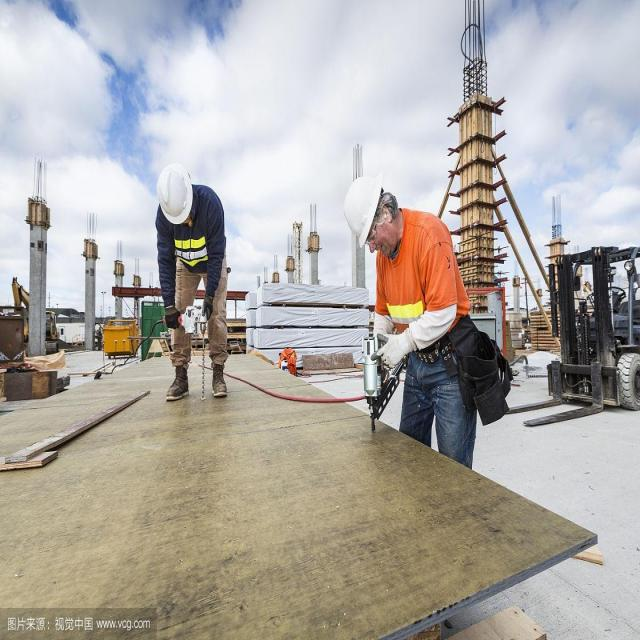

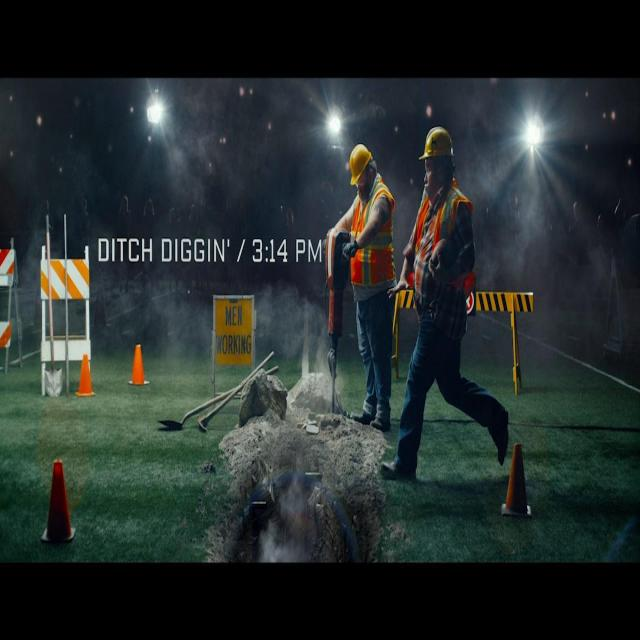

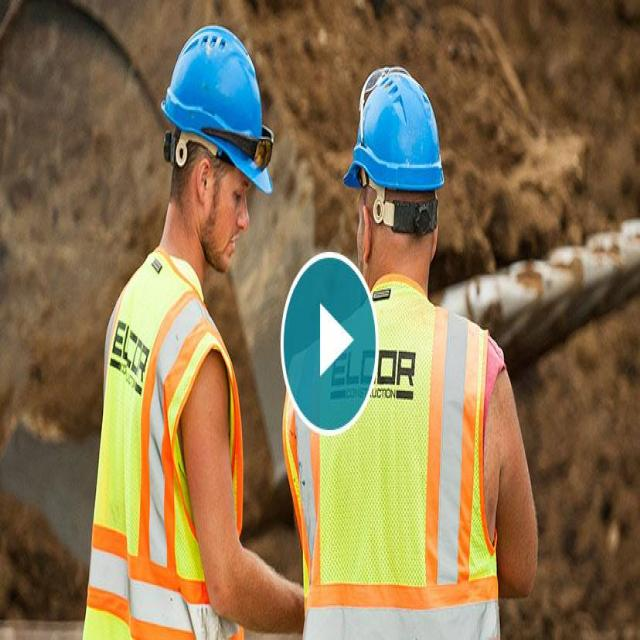

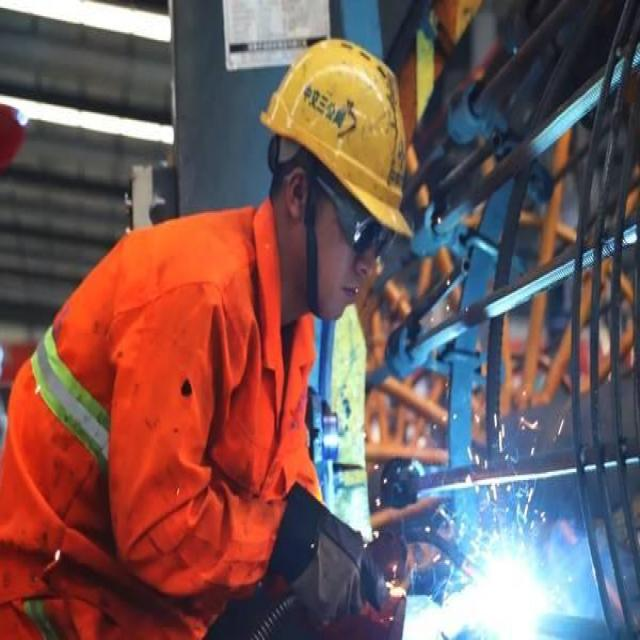

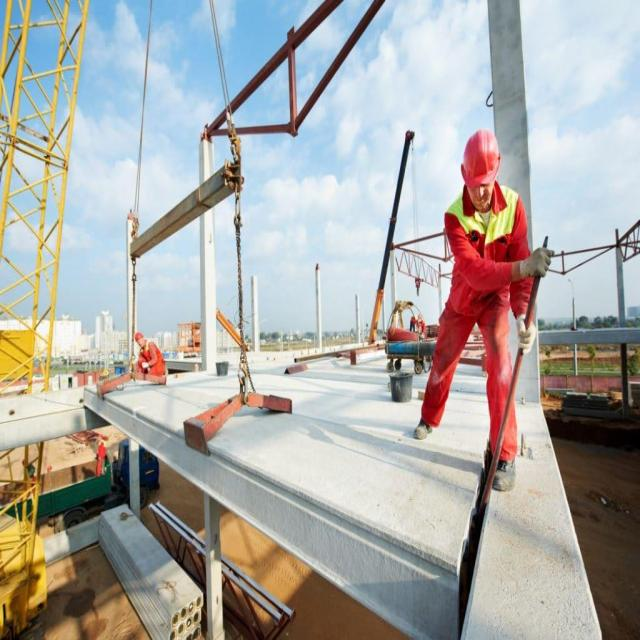

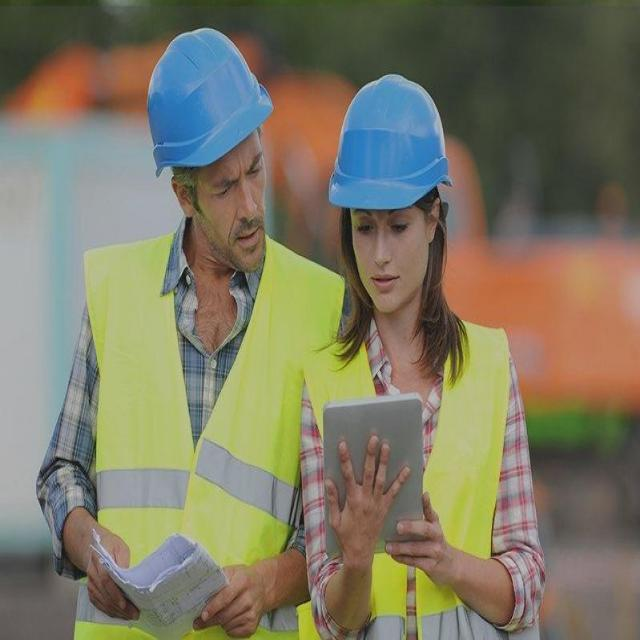

In [10]:
sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:6]

for img in sample_images:
    display(Image(filename=img, width=400))

## Step 8: Load Pretrained YOLO Model

Recommended for lab:
- `yolov8n.pt` = fast and lightweight
- `yolov8s.pt` = better accuracy but slower

In [11]:
model = YOLO("yolov8n.pt")
print("YOLOv8 nano model loaded successfully.")

YOLOv8 nano model loaded successfully.


## Step 9: Train Weapon Detection Model

In [12]:
results = model.train(
    data=data_yaml_path,
    epochs=5,
    imgsz=640,
    batch=8,
    name="construction-safety_yolov8_roboflow"
)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/construction-safety-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=construction-safety_yol

## Step 10: Display Training Results

Important files:
- `results.png`
- `confusion_matrix.png`
- `PR_curve.png`
- `F1_curve.png`


 results.png


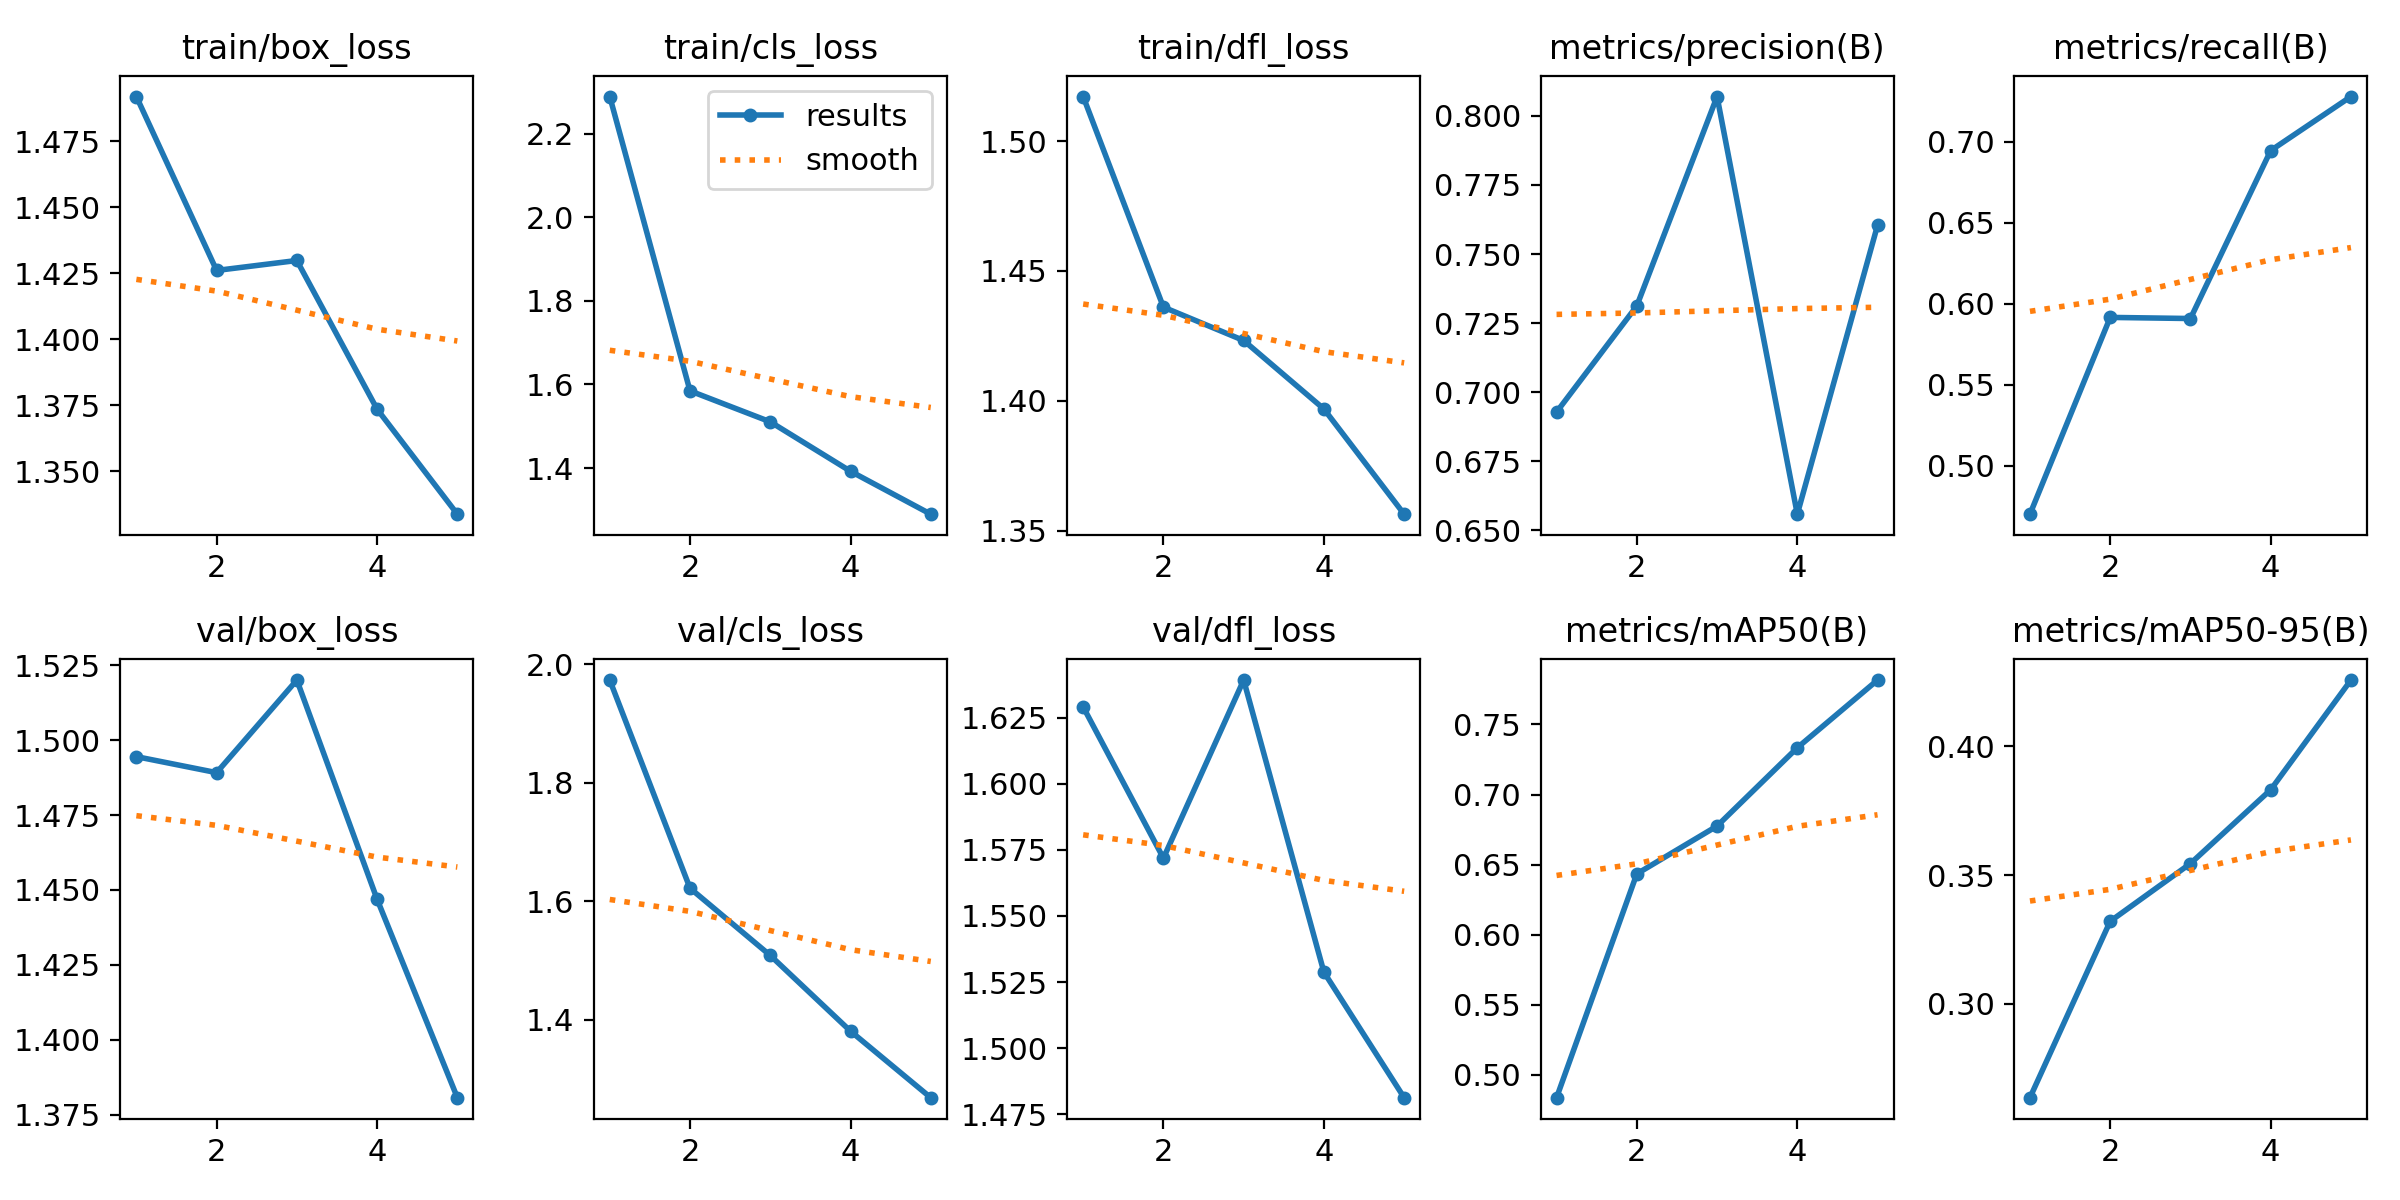


 confusion_matrix.png


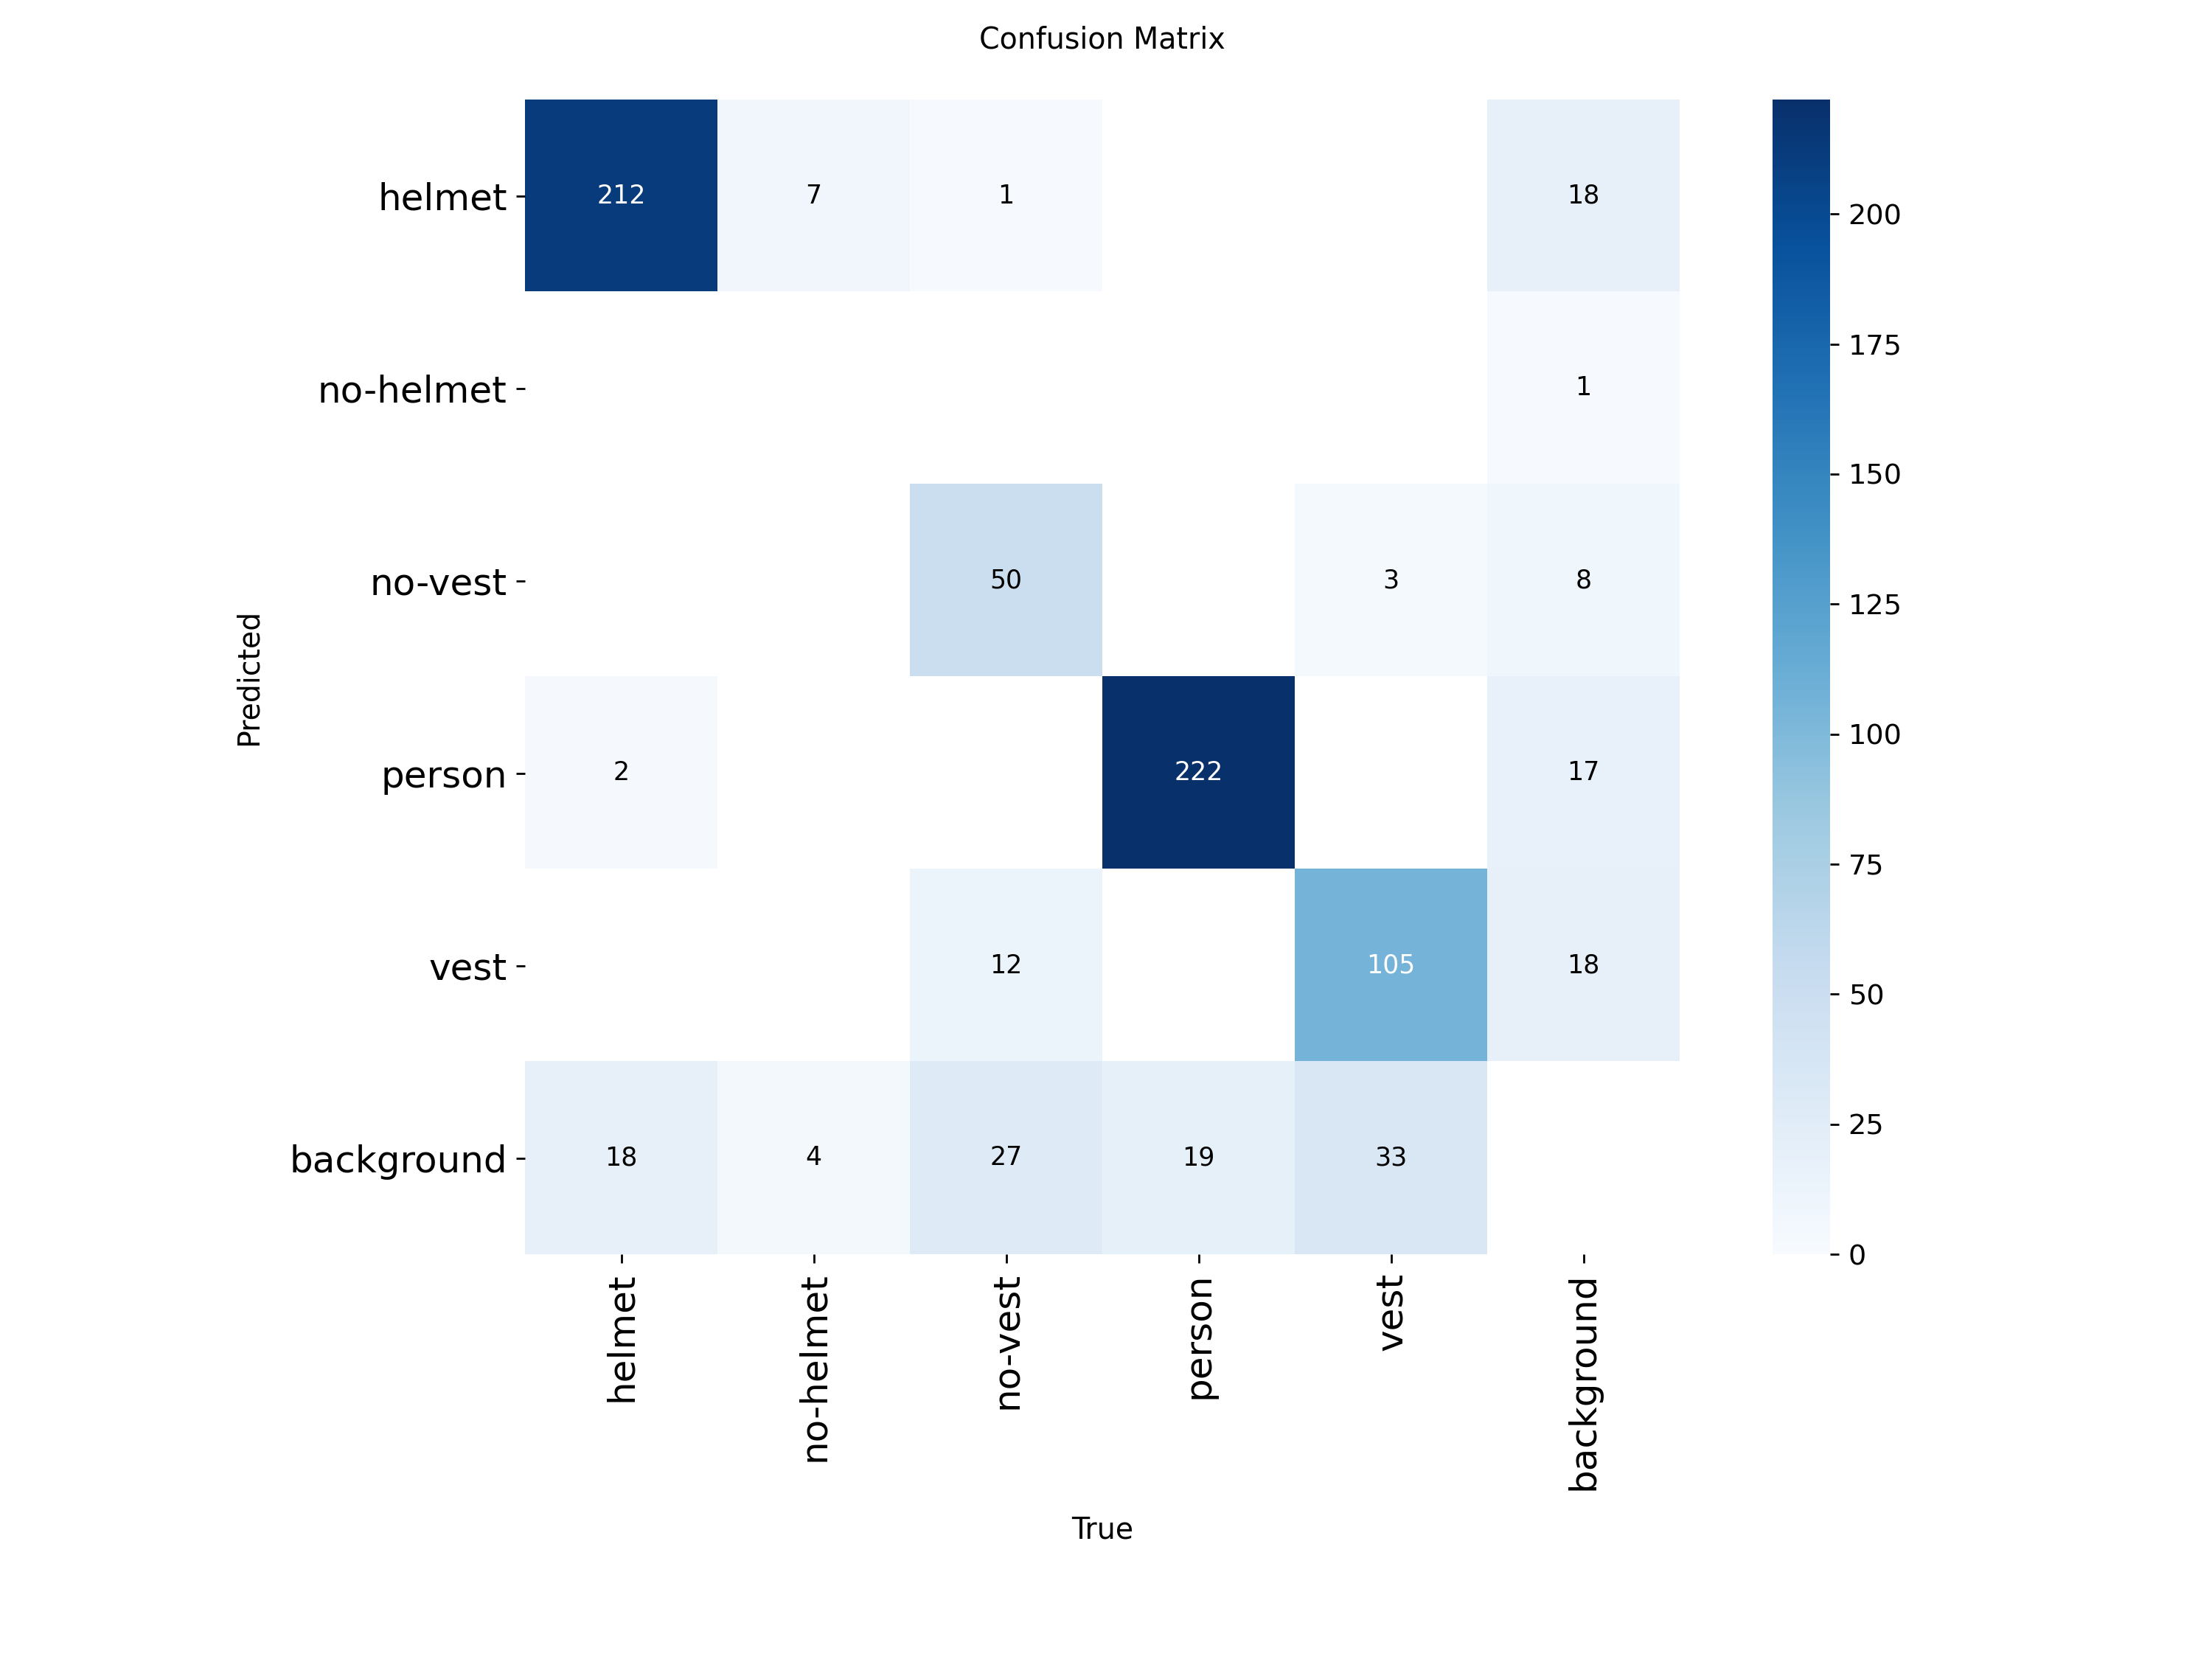

Not found: PR_curve.png
Not found: F1_curve.png
Not found: P_curve.png
Not found: R_curve.png


In [13]:
train_run_dir = "runs/detect/construction-safety_yolov8_roboflow"

result_files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in result_files:
    path = os.path.join(train_run_dir, file)
    if os.path.exists(path):
        print("\n", file)
        display(Image(filename=path, width=800))
    else:
        print("Not found:", file)

## Step 11: Validate the Trained Model

In [14]:
best_model_path = os.path.join(train_run_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path)

print("Validation completed.")

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1858.7±652.2 MB/s, size: 68.0 KB)
val: Scanning /content/construction-safety-1/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 38.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.4it/s 3.4s
                   all        119        715      0.733      0.727      0.775      0.425
                helmet        117        232       0.81      0.931      0.938      0.531
             no-helmet          6         11      0.589      0.262      0.399       0.15
               no-vest         52         90      0.762      0.689       0.76      0.339
                person        115        241      0.859      0.942      0.947      0.623
                  vest         74   

## Step 12: Test on Roboflow Test Images

In [17]:
test_results = best_model.predict(
    source=test_img_dir,
    conf=0.4,
    save=True,
    name="safety_detection_test_predictions"
)

print("Prediction completed on test images.")


image 1/90 /content/construction-safety-1/test/images/ppe_0000_jpg.rf.12dba82119baadab649f2fb1fda2afff.jpg: 640x640 1 helmet, 1 person, 53.7ms
image 2/90 /content/construction-safety-1/test/images/ppe_0004_jpg.rf.15485d516145ed09a31de9762ed5b908.jpg: 640x640 3 helmets, 3 persons, 1 vest, 34.5ms
image 3/90 /content/construction-safety-1/test/images/ppe_0008_jpg.rf.628c03cd91df99daf62577fddb1d3032.jpg: 640x640 1 helmet, 4 persons, 3 vests, 15.4ms
image 4/90 /content/construction-safety-1/test/images/ppe_0009_jpg.rf.f4e0d47f883e624b2d5fa39827068a1c.jpg: 640x640 2 helmets, 2 persons, 2 vests, 9.9ms
image 5/90 /content/construction-safety-1/test/images/ppe_0013_jpg.rf.8b5f9624055be39335d2ac101a8efe0d.jpg: 640x640 1 helmet, 1 person, 7.3ms
image 6/90 /content/construction-safety-1/test/images/ppe_0014_jpg.rf.85eab056e0d78bf348203a261683723f.jpg: 640x640 3 persons, 7.2ms
image 7/90 /content/construction-safety-1/test/images/ppe_0038_jpg.rf.54e8b1b9118cfc56b4a4a3606995e749.jpg: 640x640 4 helm

## Step 13: Display Test Prediction Images

Number of predicted images: 90


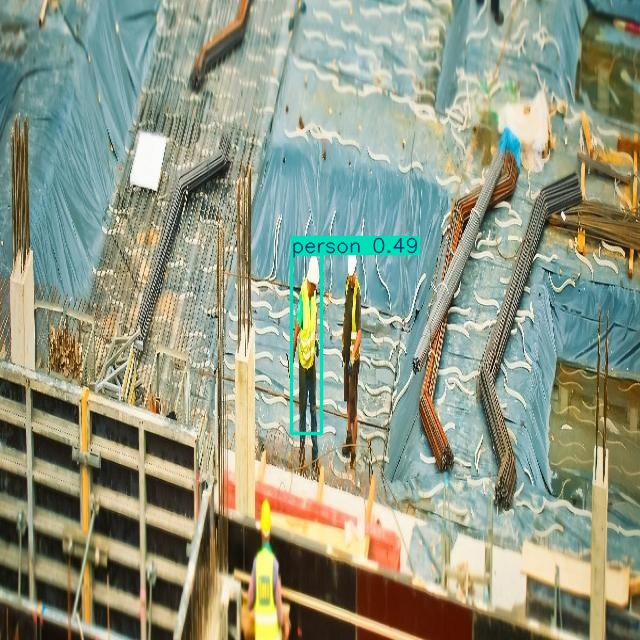

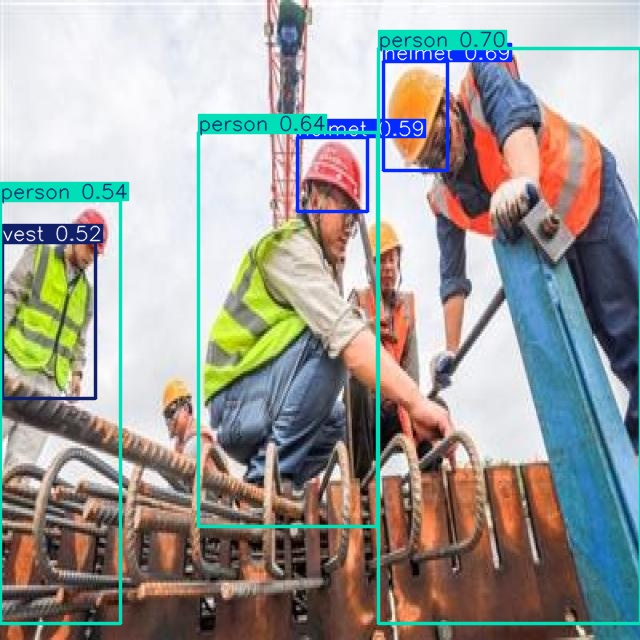

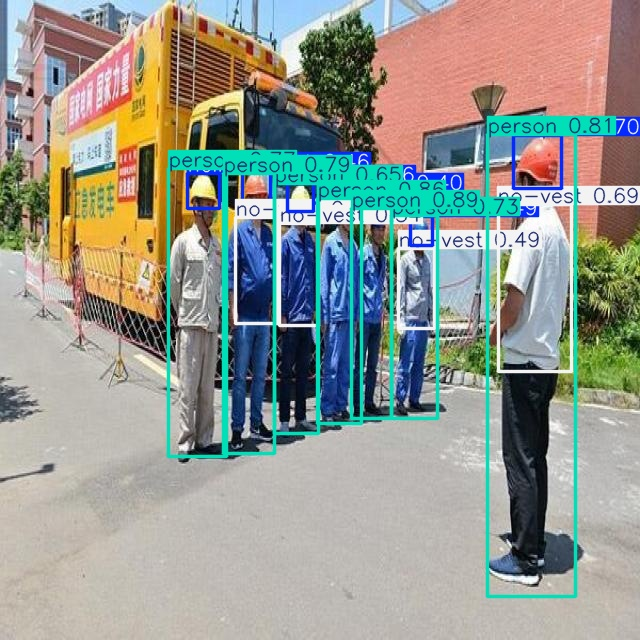

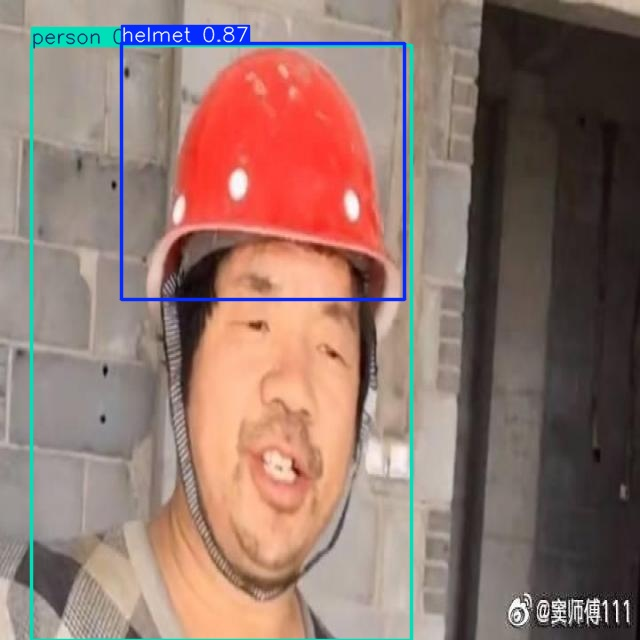

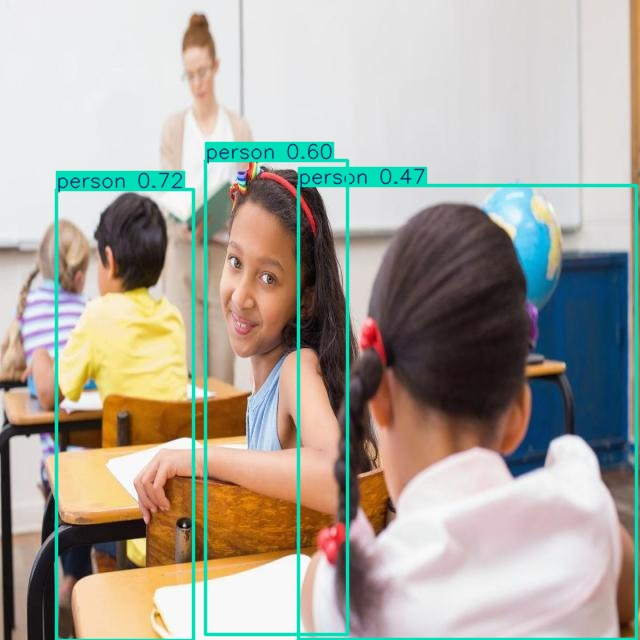

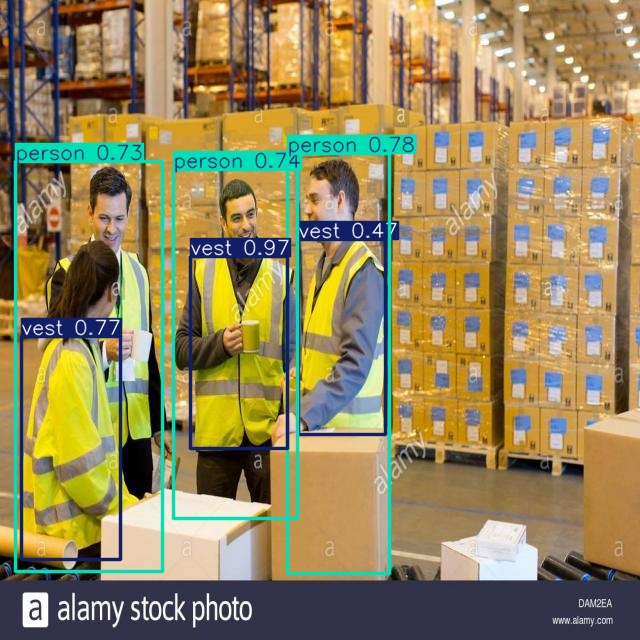

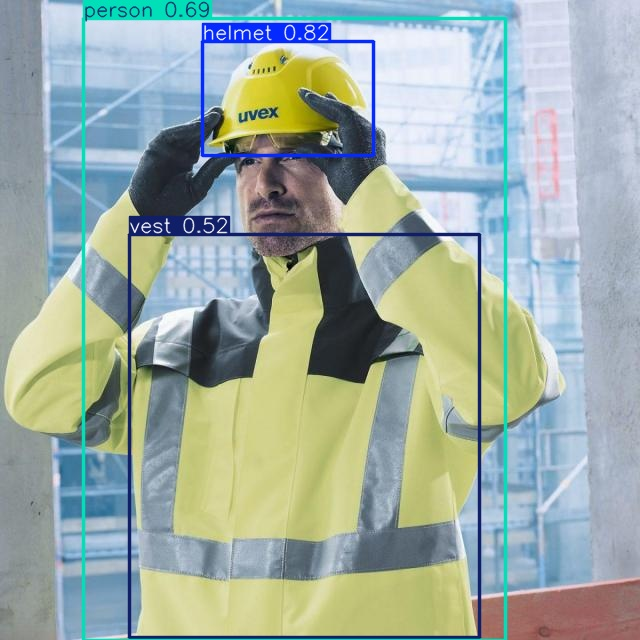

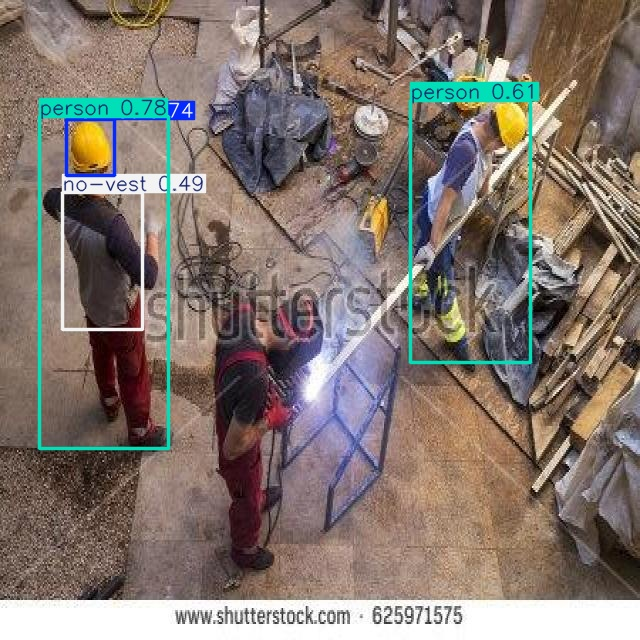

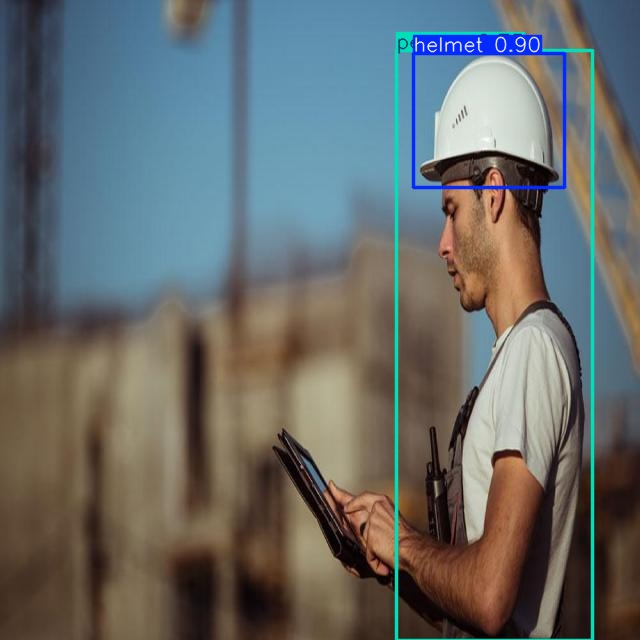

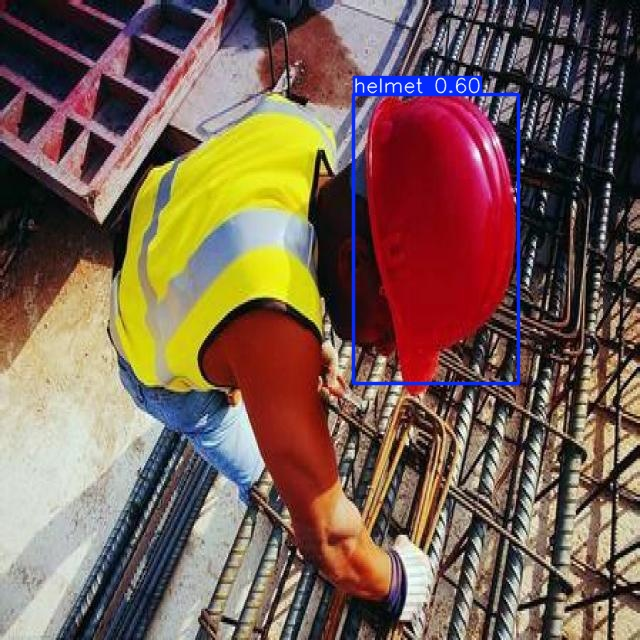

In [18]:
prediction_dir = "runs/detect/safety_detection_test_predictions"
predicted_images = glob.glob(os.path.join(prediction_dir, "*"))

print("Number of predicted images:", len(predicted_images))

for img in predicted_images[:10]:
    display(Image(filename=img, width=600))

## Step 14: Test on a New Uploaded Image

In [20]:
uploaded = files.upload()
uploaded_image = list(uploaded.keys())[0]

single_result = best_model.predict(
    source=uploaded_image,
    conf=0.4,
    save=True,
    name="safety_detection_uploaded_image"
)

print("Prediction completed on uploaded image.")

Saving imagesconstructionsafety.jpg to imagesconstructionsafety (1).jpg

image 1/1 /content/imagesconstructionsafety (1).jpg: 640x576 1 helmet, 1 person, 1 vest, 8.4ms
Speed: 3.7ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 576)
Results saved to /content/runs/detect/safety_detection_uploaded_image
Prediction completed on uploaded image.


## Step 15: Display Uploaded Image Prediction

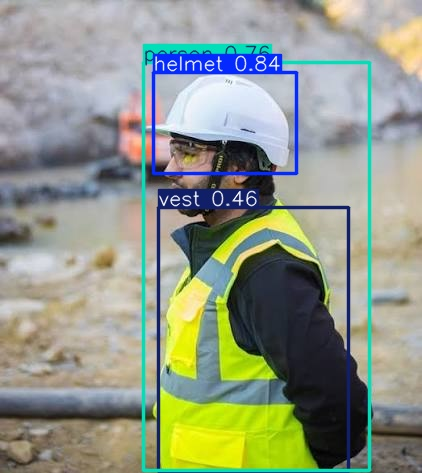

In [21]:
uploaded_prediction_dir = "runs/detect/safety_detection_uploaded_image"
uploaded_pred_images = glob.glob(os.path.join(uploaded_prediction_dir, "*"))

for img in uploaded_pred_images:
    display(Image(filename=img, width=700))

## Step 16: Extract Detected Object Names and Confidence Scores

In [22]:
detections = []

for result in single_result:
    names = result.names

    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = names[cls_id]

        detections.append({
            "Detected Object": label,
            "Confidence Score": round(conf, 3)
        })

if len(detections) == 0:
    print("No safety object detected.")
else:
    display(pd.DataFrame(detections))

,Detected Object,Confidence Score
0,helmet,0.838
1,person,0.765
2,vest,0.462


# **Conclusion**

**Bounding Boxes**

In helmet detection, a bounding box identifies the location of the detected object, such as a helmet, worker, or other safety-related object, within the image. The model predicts the coordinates of the bounding box, defining the rectangular region where the detected object is located.

Bounding boxes are important because simply knowing that a helmet exists somewhere in an image is not sufficient for a safety-monitoring system. The system needs to identify where the detected object is located and which worker it is associated with.

For example, suppose an image contains five workers. YOLO may produce multiple bounding boxes, with each box identifying the location of a detected object. The corresponding class label and confidence score are associated with each bounding box, allowing the system to determine what was detected and how confident the model is about the detection.

**Class Labels**

A class label tells us what the detected object represents. For this project, the original Roboflow dataset contains five classes:

['helmet', 'no-helmet', 'no-vest', 'person', 'vest']

For example, if the model detects a worker wearing a safety helmet, it may draw a bounding box around the helmet and assign the class label: Helmet

Similarly, if a worker is detected without a helmet, the model may assign: No Helmet

The purpose of the safety-monitoring system is not simply to detect workers or objects. It is to determine whether workers are complying with the required safety equipment requirements. Therefore, the helmet and no-helmet labels are particularly important for identifying potential helmet-safety violations.

**Confidence Score**

A confidence score represents how confident the model is that a particular detected object belongs to a particular class.

For example: Helmet 0.94

This means that the model has assigned a confidence score of 0.94 to the detection and considers it a strong prediction.

The confidence score generally ranges from 0 to 1, where a higher value indicates greater model confidence in the detection.

**How the Three Components Work Together**

The real strength of YOLO object detection comes from combining the bounding box, class label, and confidence score.

For example, suppose the output of the detection information is represented as:

Bounding Box → [120, 80, 250, 210]
Class        → Helmet
Confidence   → 0.94

This means that:

Bounding Box identifies where the detected object is located.
Class Label identifies what the detected object is.
Confidence Score indicates how confident the model is about the detection.

Therefore, the model has detected an object at the specified location, classified it as Helmet, and assigned a confidence score of 0.94.

Together, these three components enable YOLO to identify and localize safety-related objects in construction-site images and help the safety-monitoring system identify workers who may not be wearing the required safety helmet.